# GRU Seq2Seq
history_len = 30  
horizon = 5  
n_trials = 200  
lr_scheduler.ReduceLROnPlateau

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from src.visualization import evaluate_and_plot_full_forecast
from src.models.rnn.rnn_seq2seq import RNNSeq2Seq, Encoder, Decoder
from src.models.rnn.train_rnn_seq2seq import train_rnn_seq2seq
from src.models.rnn.data_preparing import (
    create_seq2seq_eval_loader,
    create_seq2seq_train_loader
)
from src.models.rnn.predict import predict_seq2seq
from src.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
set_seed(SEED)

In [3]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [4]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [5]:
borehole_name = '48-1'
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
feature_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']

history_len = 30
horizon = 5

df_train_full = df_train_full[feature_cols + target_cols]
df_train = df_train[feature_cols + target_cols]
df_val = df_val[feature_cols + target_cols]
df_test = df_test[feature_cols + target_cols]

In [6]:
batch_size = 64

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()


train_loader = create_seq2seq_train_loader(
    df=df_train,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    batch_size=batch_size
)

full_train_loader = create_seq2seq_train_loader(
    df=df_train_full,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=full_feature_scaler,
    target_scaler=full_target_scaler,
    batch_size=batch_size
)

val_loader = create_seq2seq_eval_loader(
    df_eval=df_val,
    df_start=df_train,
    history_len=history_len,
    horizon=horizon,
    feature_cols=feature_cols,
    target_cols=target_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    batch_size=batch_size
)

In [7]:
input_size = len(feature_cols) + len(target_cols)
feature_size = len(feature_cols)
target_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    set_seed(SEED + trial.number)
    hidden_size = trial.suggest_int('hidden_size', 16, 160, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 4)
    
    if num_layers == 1:
        dropout = 0.0
    else:
        dropout = trial.suggest_float('dropout', 0.0, 0.4)
    
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    
    encoder_trial = Encoder(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type='gru'
    )
    
    decoder_trial = Decoder(
        feature_size=feature_size,
        target_size=target_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type='gru'
    )
    
    model_trial = RNNSeq2Seq(
        encoder=encoder_trial,
        decoder=decoder_trial,
        target_size=len(target_cols)
    ).to(device)
    
    optimizer_trial = optim.AdamW(
        model_trial.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial,
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
    model_trial, history = train_rnn_seq2seq(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        teacher_forcing_ratio=0.5,
        scheduler=scheduler,
        device=device,
        epochs=150,
        max_epochs_no_improvement=15,
        verbose=False
    )
    
    trial.set_user_attr('actual_dropout', dropout)
    trial.set_user_attr('best_epoch', history['best_epoch'])
    trial.set_user_attr('total_epochs', len(history['val_rmse']))
    
    best_val_rmse = float(history['best_val_rmse'][-1])
    return best_val_rmse

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=200)

print('Лучшие параметры: ', study.best_params)
print('Количество эпох в лучшем запуске: ', study.best_trial.user_attrs['total_epochs'])

[I 2026-06-19 18:52:58,743] A new study created in memory with name: no-name-19fb898c-df14-45c9-b77f-154f6291d7fe
[I 2026-06-19 18:53:41,322] Trial 0 finished with value: 0.10722160339355469 and parameters: {'hidden_size': 64, 'num_layers': 4, 'dropout': 0.292797576724562, 'lr': 0.00015751320499779721, 'weight_decay': 2.0513382630874486e-05}. Best is trial 0 with value: 0.10722160339355469.


Early stopping on 147 epoch


[I 2026-06-19 18:54:06,125] Trial 1 finished with value: 0.09236203134059906 and parameters: {'hidden_size': 32, 'num_layers': 1, 'lr': 0.0005399484409787432, 'weight_decay': 0.00015930522616241006}. Best is trial 1 with value: 0.09236203134059906.
[I 2026-06-19 18:54:32,735] Trial 2 finished with value: 0.06822581589221954 and parameters: {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0008706020878304854, 'weight_decay': 0.000462258900102083}. Best is trial 2 with value: 0.06822581589221954.
[I 2026-06-19 18:54:57,969] Trial 3 finished with value: 0.2228497862815857 and parameters: {'hidden_size': 48, 'num_layers': 1, 'lr': 2.3270677083837777e-05, 'weight_decay': 4.059611610484306e-05}. Best is trial 2 with value: 0.06822581589221954.
[I 2026-06-19 18:55:25,753] Trial 4 finished with value: 0.0812714621424675 and parameters: {'hidden_size': 96, 'num_layers': 2, 'dropout': 0.11649165607921677, 'lr': 0.00016738085788752134, 'weight_decay': 1.9010245319870364e-05}. Best is trial 2 with va

Early stopping on 132 epoch


[I 2026-06-19 18:55:51,097] Trial 5 finished with value: 0.09453477710485458 and parameters: {'hidden_size': 48, 'num_layers': 2, 'dropout': 0.1824279936868144, 'lr': 0.00037183641805732076, 'weight_decay': 2.5081156860452307e-05}. Best is trial 2 with value: 0.06822581589221954.


...

Early stopping on 85 epoch


[I 2026-06-19 20:10:06,729] Trial 197 finished with value: 0.06799890846014023 and parameters: {'hidden_size': 160, 'num_layers': 1, 'lr': 0.0007516235885016944, 'weight_decay': 0.00012748204286443053}. Best is trial 21 with value: 0.05895838886499405.
[I 2026-06-19 20:10:28,963] Trial 198 finished with value: 0.06170656159520149 and parameters: {'hidden_size': 160, 'num_layers': 1, 'lr': 0.0008283501967153839, 'weight_decay': 0.00015243145079104552}. Best is trial 21 with value: 0.05895838886499405.


Early stopping on 136 epoch


[I 2026-06-19 20:10:48,042] Trial 199 finished with value: 0.06980213522911072 and parameters: {'hidden_size': 160, 'num_layers': 1, 'lr': 0.0007070971853680226, 'weight_decay': 0.0001396663259843249}. Best is trial 21 with value: 0.05895838886499405.


Early stopping on 115 epoch
Лучшие параметры:  {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0009326422725040234, 'weight_decay': 0.00047197108250521144}
Количество эпох в лучшем запуске:  142


In [8]:
encoder = Encoder(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    dropout=study.best_trial.user_attrs['actual_dropout'],
    rnn_type='gru'
)

decoder = Decoder(
    feature_size=feature_size,
    target_size=target_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    dropout=study.best_trial.user_attrs['actual_dropout'],
    rnn_type='gru'
)

model = RNNSeq2Seq(
    encoder=encoder,
    decoder=decoder,
    target_size=len(target_cols)
).to(device)
optimizer = optim.AdamW(
    model.parameters(),
    lr=study.best_params['lr'],
    weight_decay=study.best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

model, _ = train_rnn_seq2seq(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    teacher_forcing_ratio=0.5,
    scheduler=scheduler,
    device=device,
    epochs=study.best_trial.user_attrs['best_epoch'],
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/127 | Train Loss: 0.7211
Epoch 2/127 | Train Loss: 0.1624
Epoch 3/127 | Train Loss: 0.0669
Epoch 4/127 | Train Loss: 0.0436
Epoch 5/127 | Train Loss: 0.0349
Epoch 6/127 | Train Loss: 0.0280
Epoch 7/127 | Train Loss: 0.0235
Epoch 8/127 | Train Loss: 0.0202
Epoch 9/127 | Train Loss: 0.0184
Epoch 10/127 | Train Loss: 0.0149
Epoch 11/127 | Train Loss: 0.0140
Epoch 12/127 | Train Loss: 0.0134
Epoch 13/127 | Train Loss: 0.0146
Epoch 14/127 | Train Loss: 0.0116
Epoch 15/127 | Train Loss: 0.0090
Epoch 16/127 | Train Loss: 0.0100
Epoch 17/127 | Train Loss: 0.0114
Epoch 18/127 | Train Loss: 0.0216
Epoch 19/127 | Train Loss: 0.0115
Epoch 20/127 | Train Loss: 0.0120
Epoch 21/127 | Train Loss: 0.0100
Epoch 22/127 | Train Loss: 0.0091
Epoch 23/127 | Train Loss: 0.0071
Epoch 24/127 | Train Loss: 0.0062
Epoch 25/127 | Train Loss: 0.0062
Epoch 26/127 | Train Loss: 0.0059
Epoch 27/127 | Train Loss: 0.0059
Epoch 28/127 | Train Loss: 0.0058
Epoch 29/127 | Train Loss: 0.0055
Epoch 30/127 | Train Lo

In [ ]:
model_path = 'models/gru_seq2seq_v5_optuna.pth'
weights_path = 'models/gru_seq2seq_v5_optuna_weights.pth'

torch.save(model, model_path)
torch.save(model.state_dict(), weights_path)

model = torch.load(model_path, weights_only=False)

                              RMSE       MAE        ME       NSE
Значение для всех глубин  0.659724  0.507414 -0.147861  0.960907


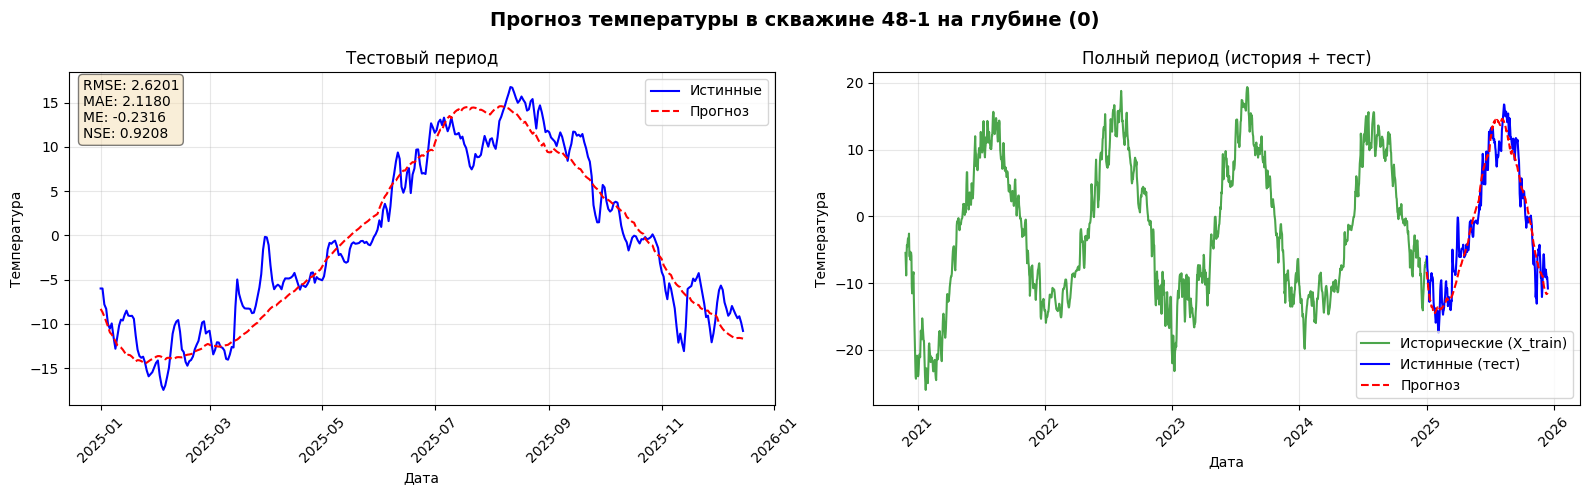

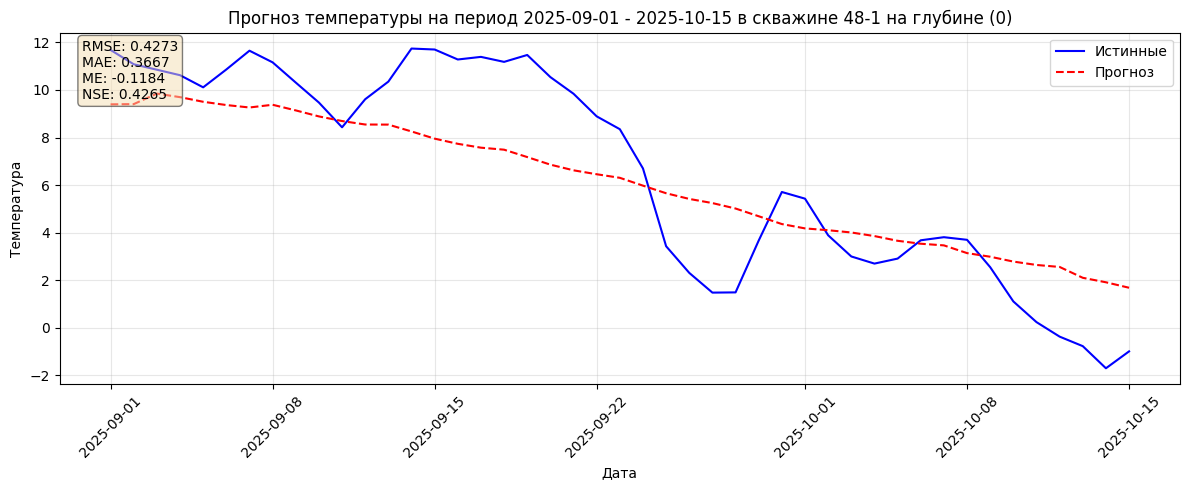

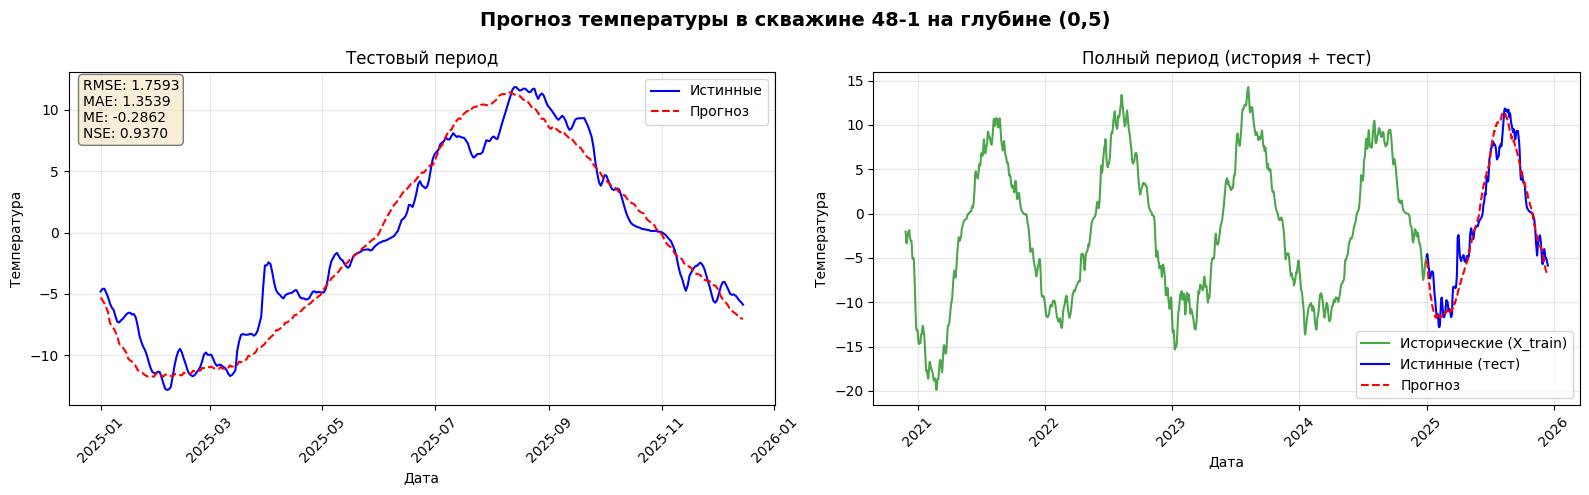

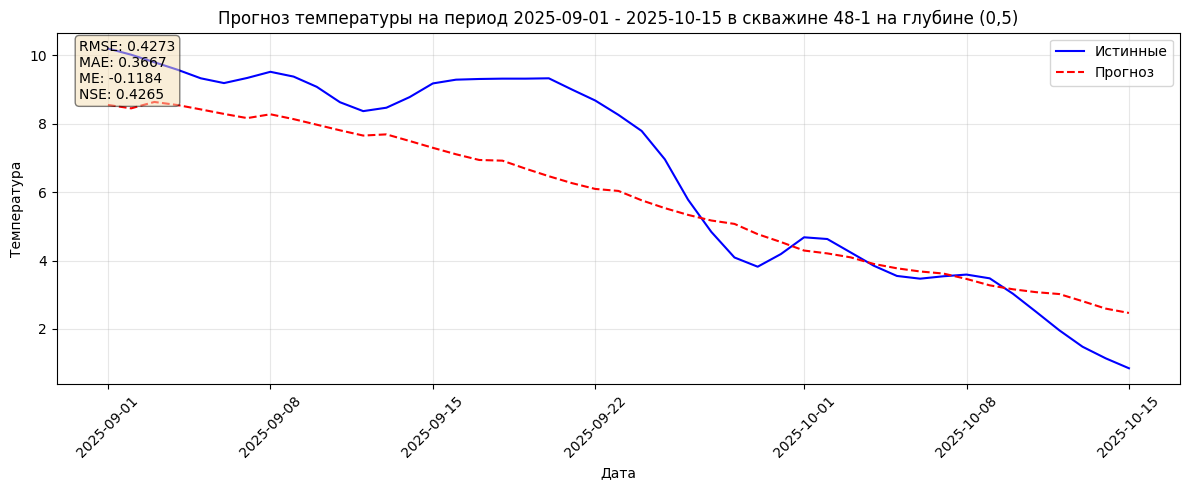

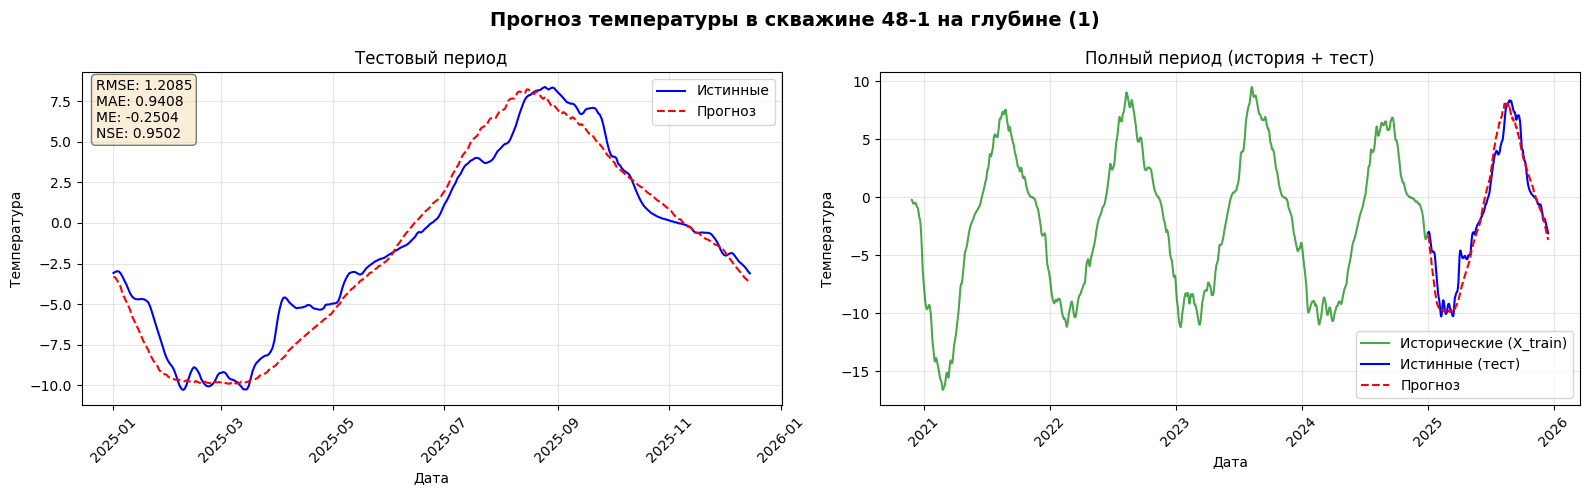

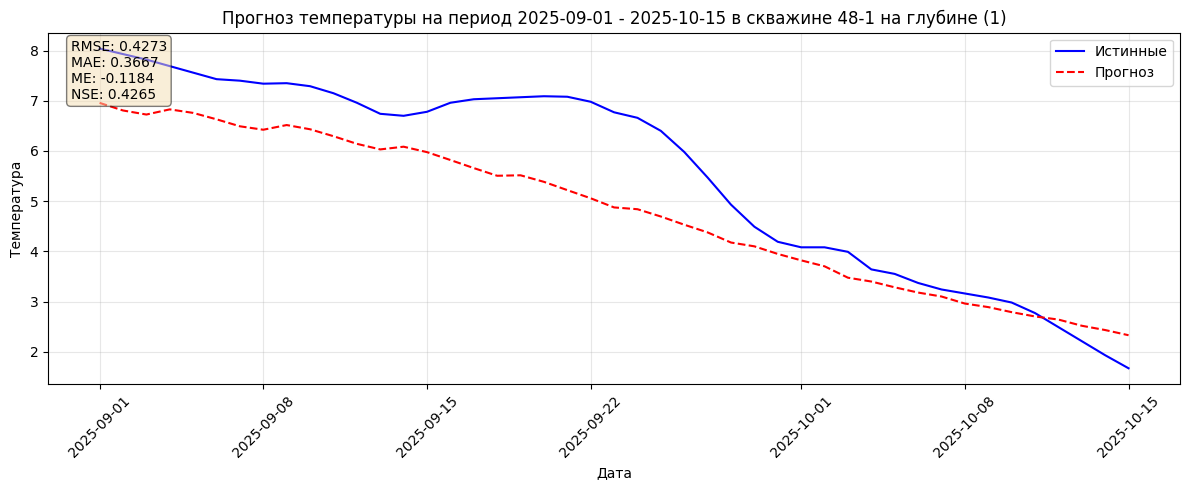

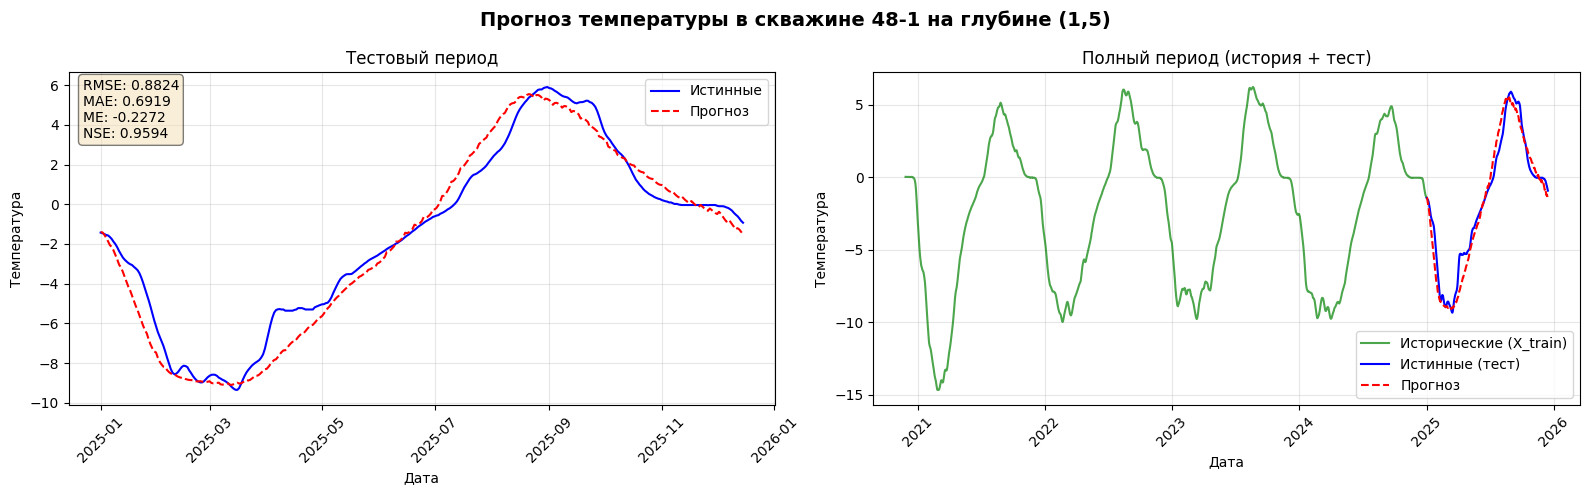

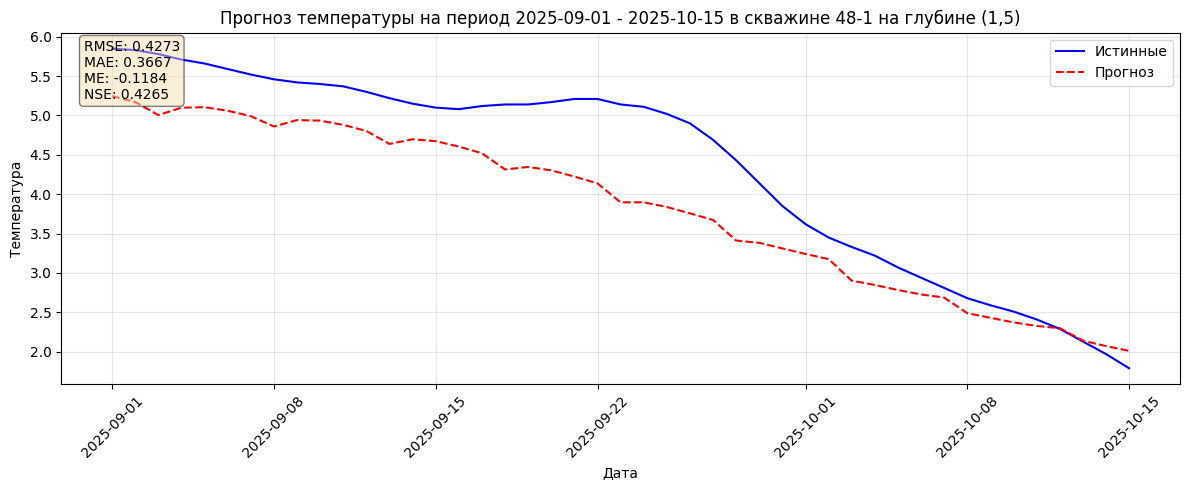

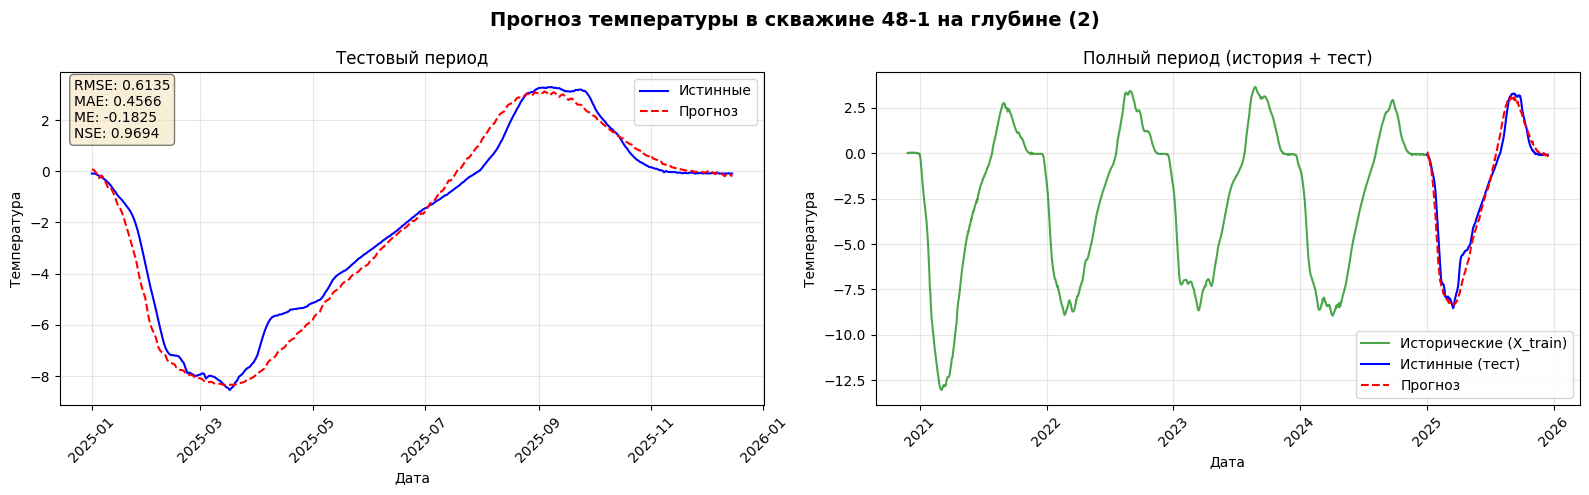

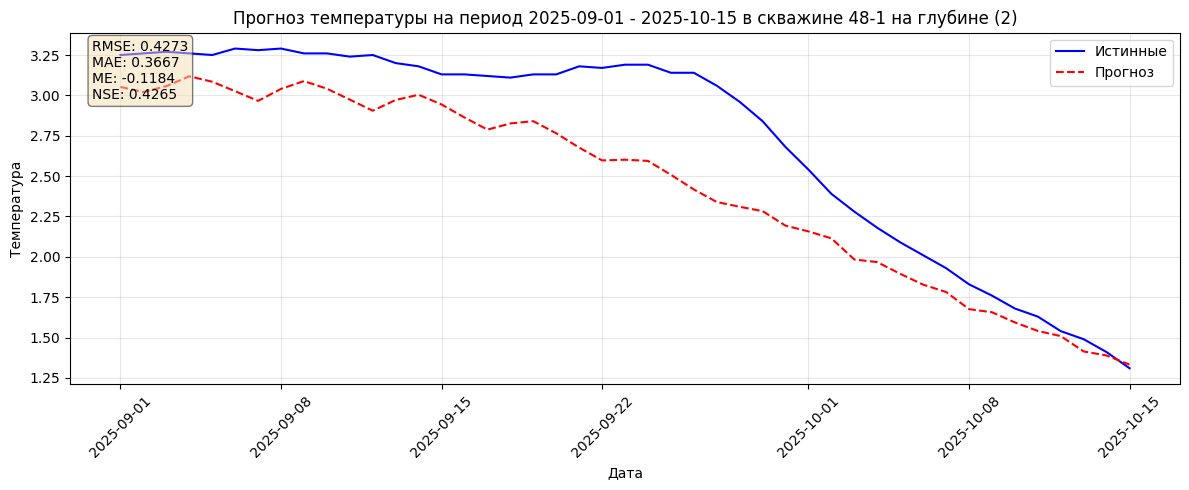

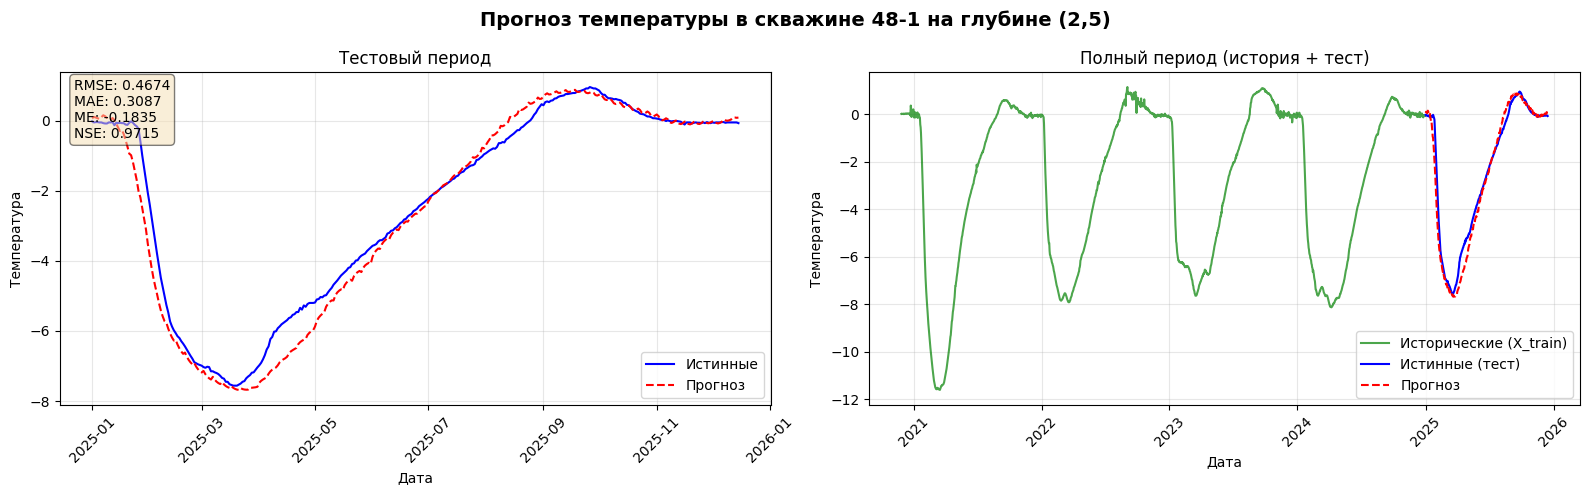

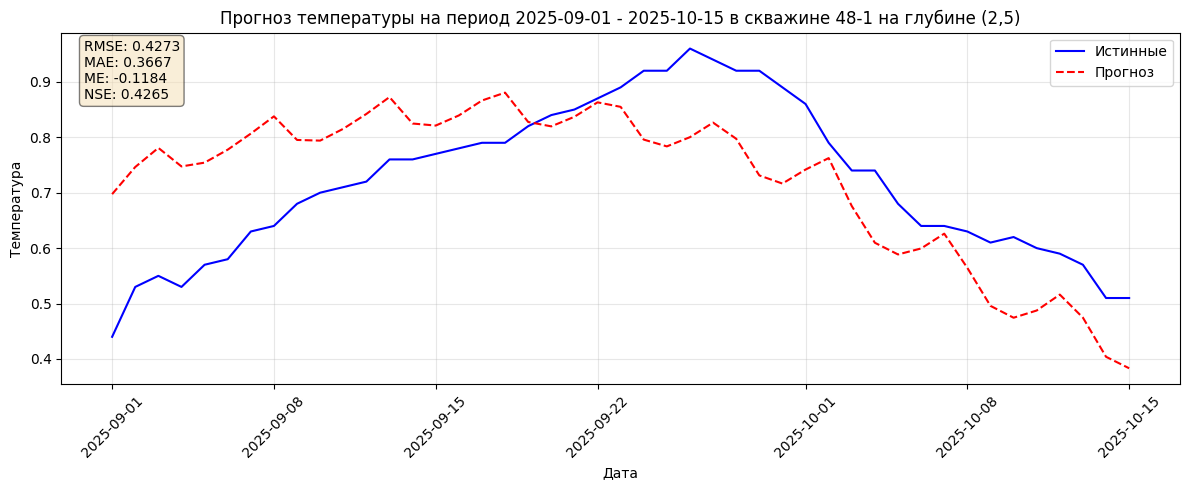

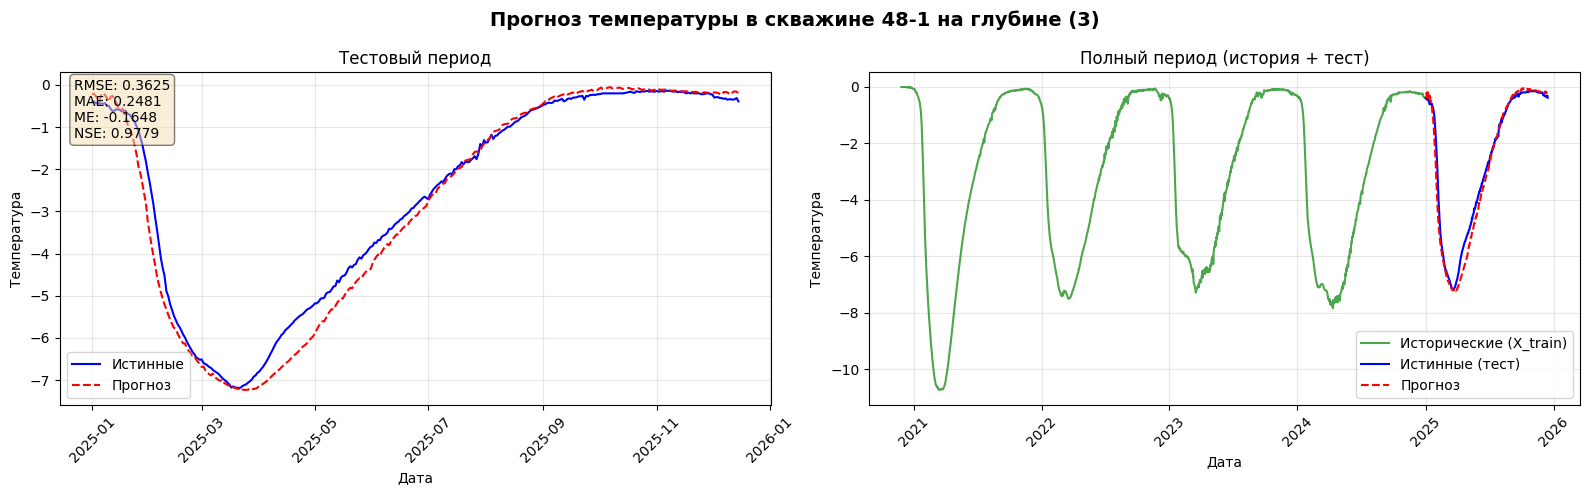

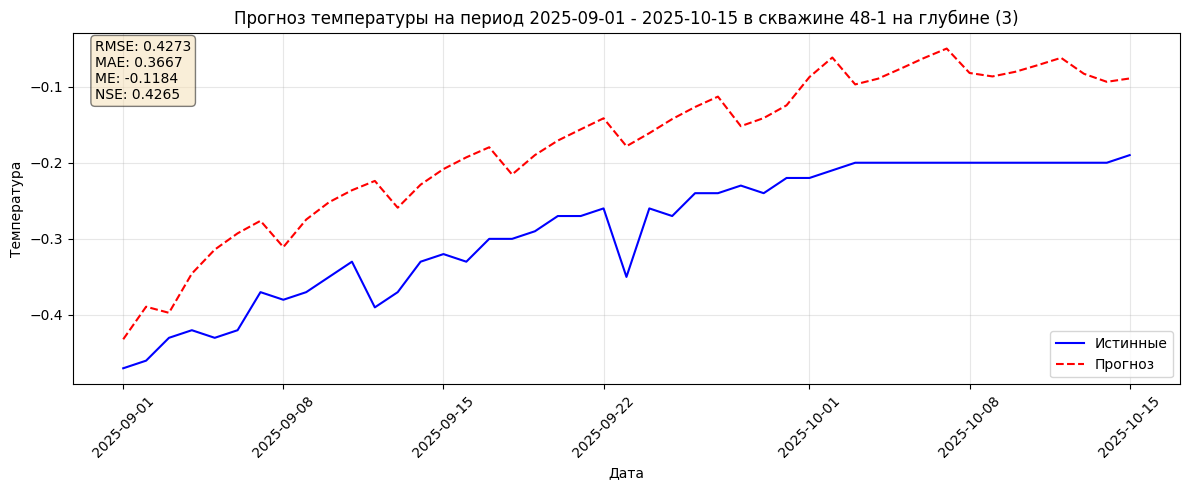

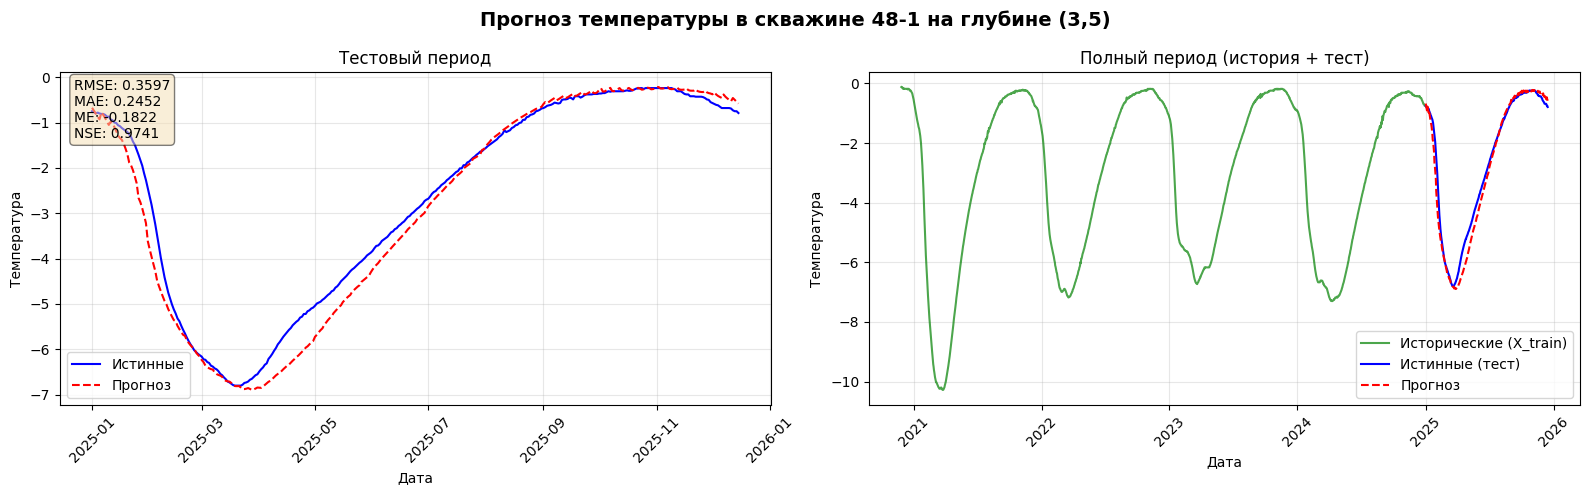

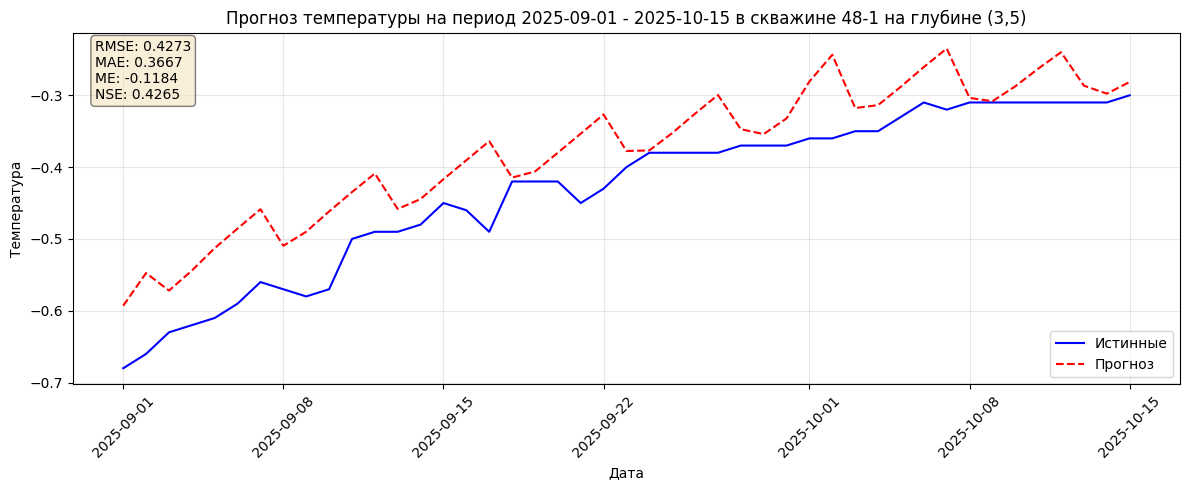

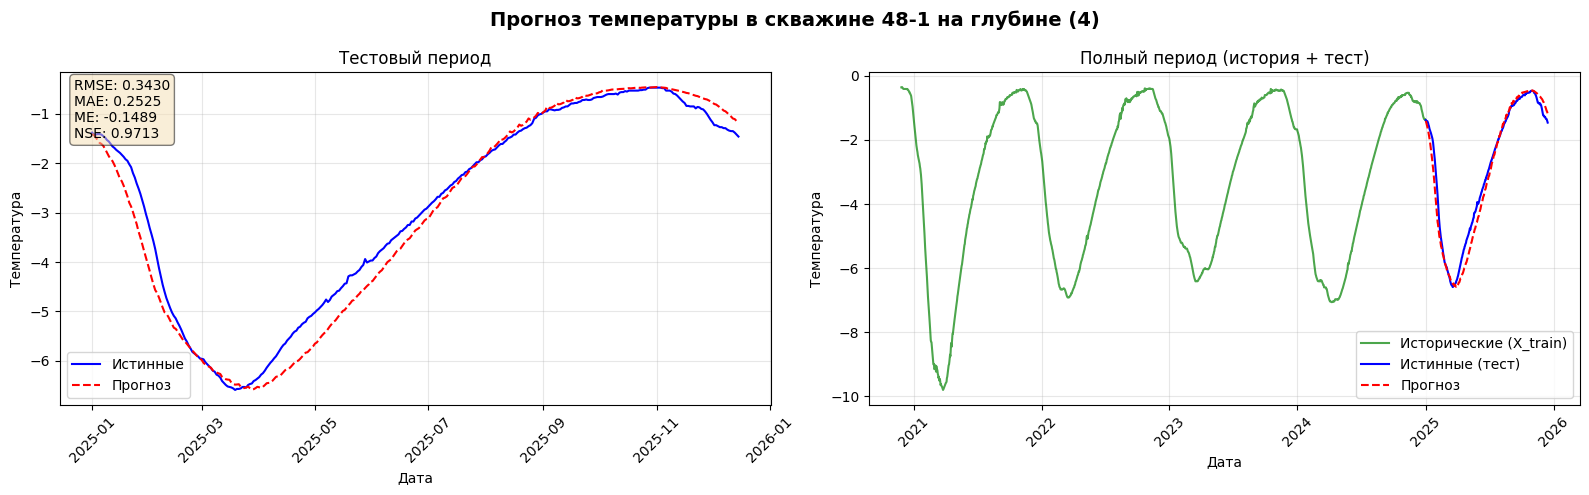

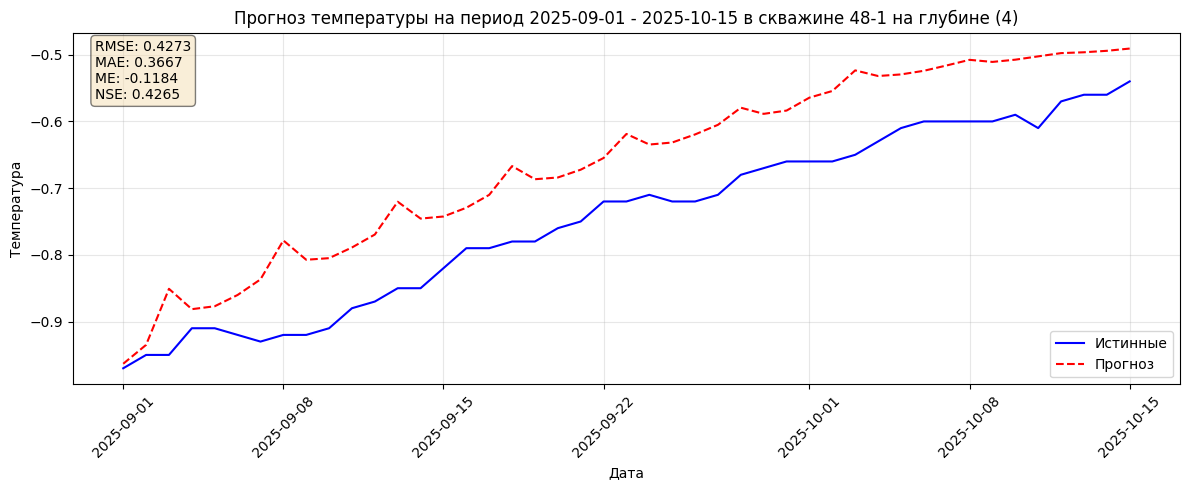

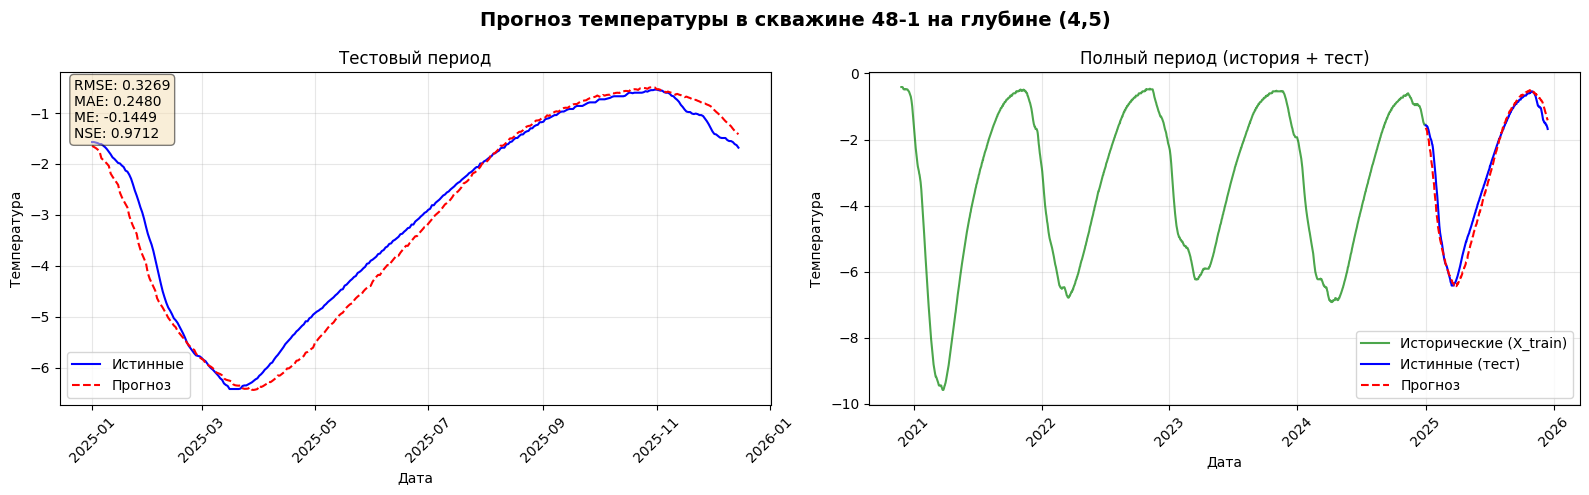

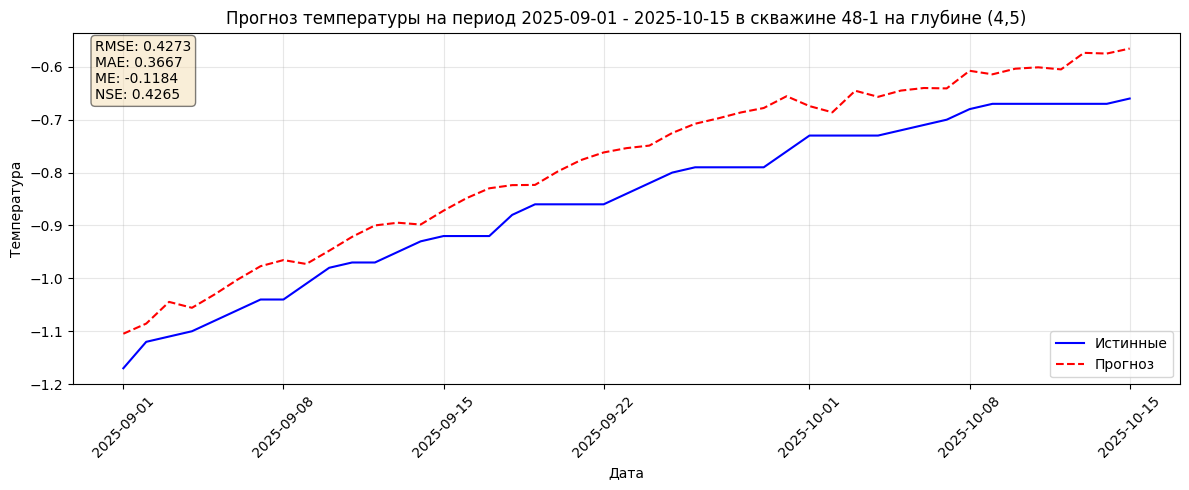

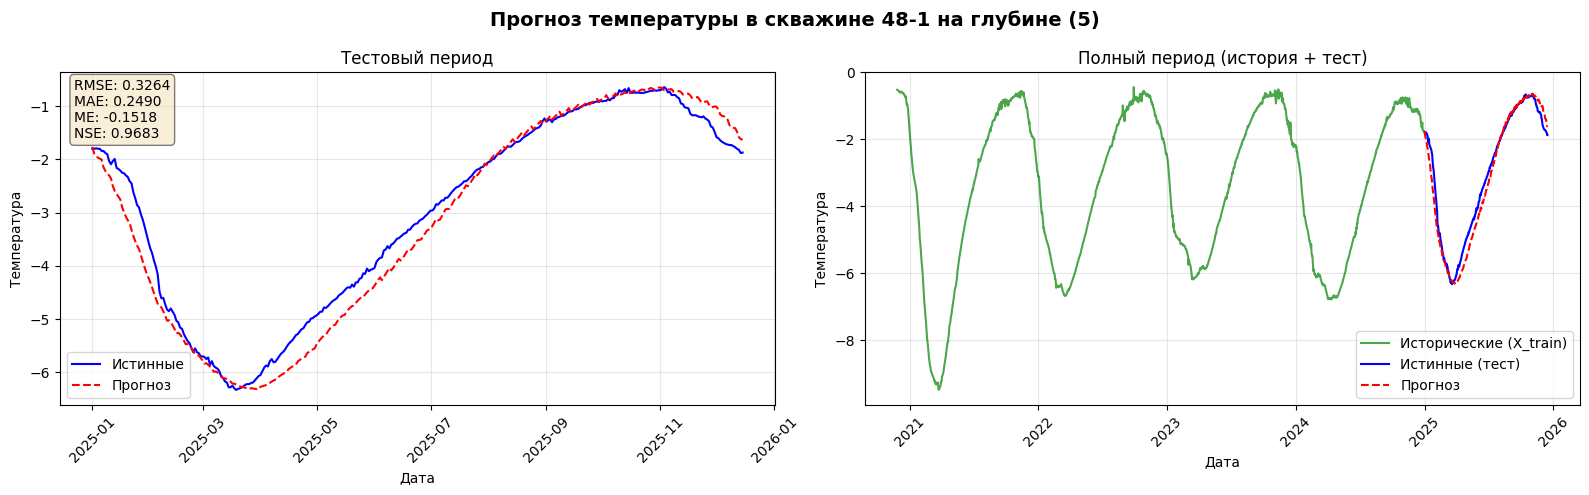

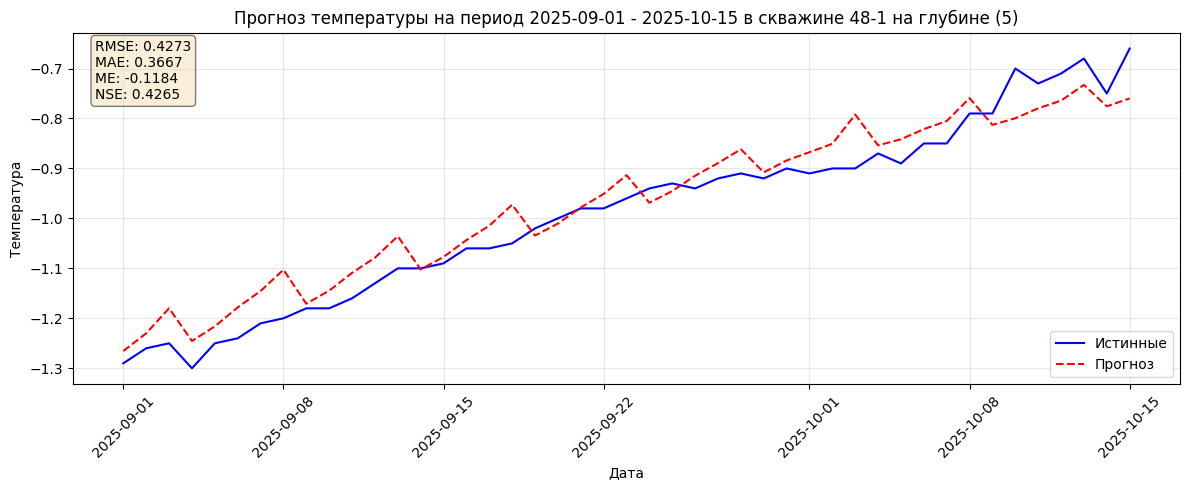

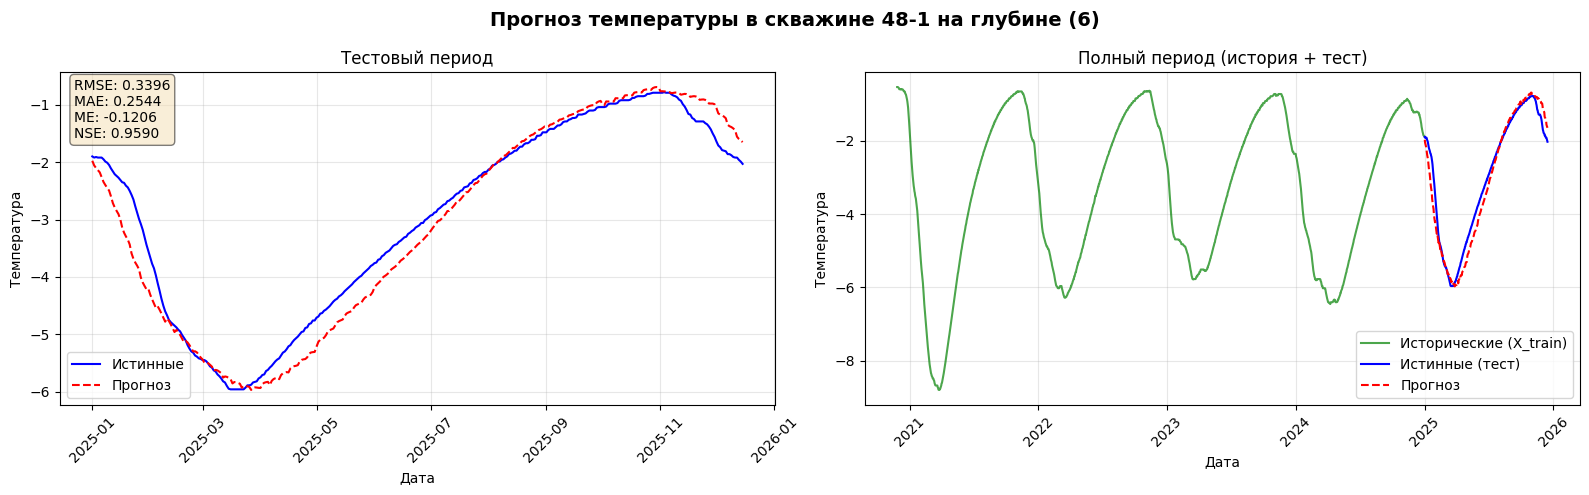

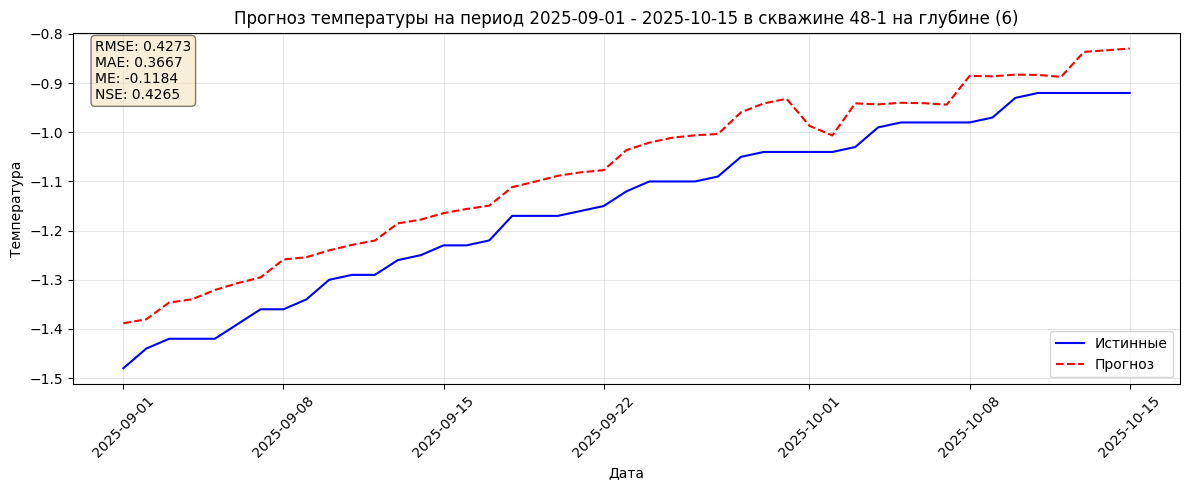

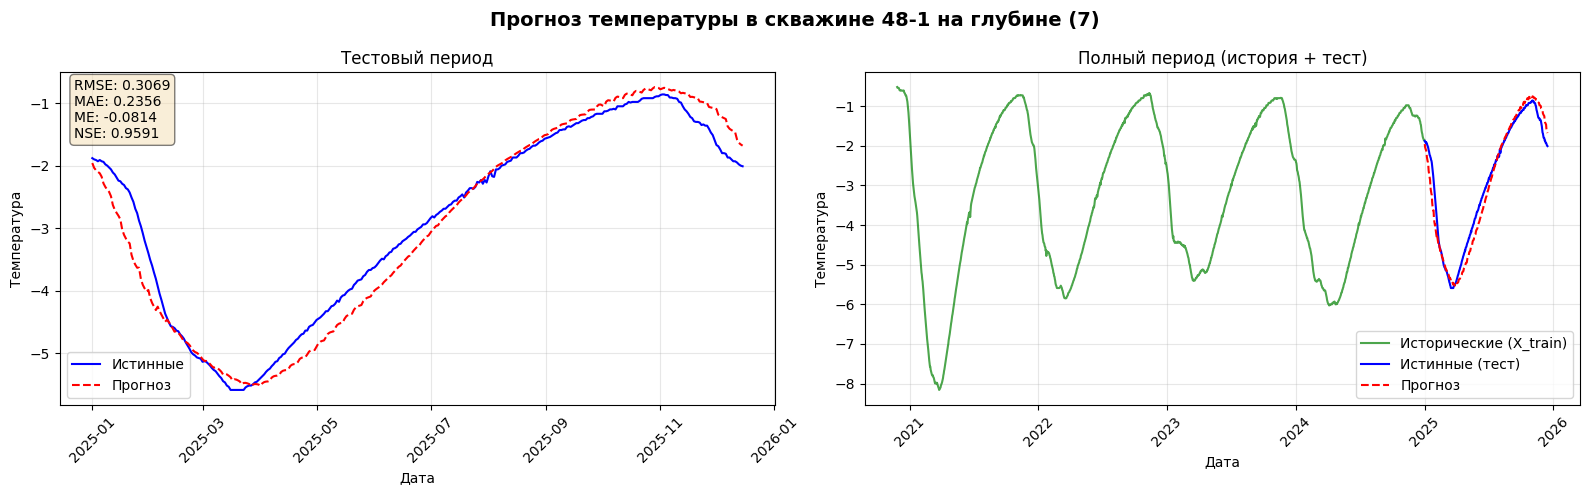

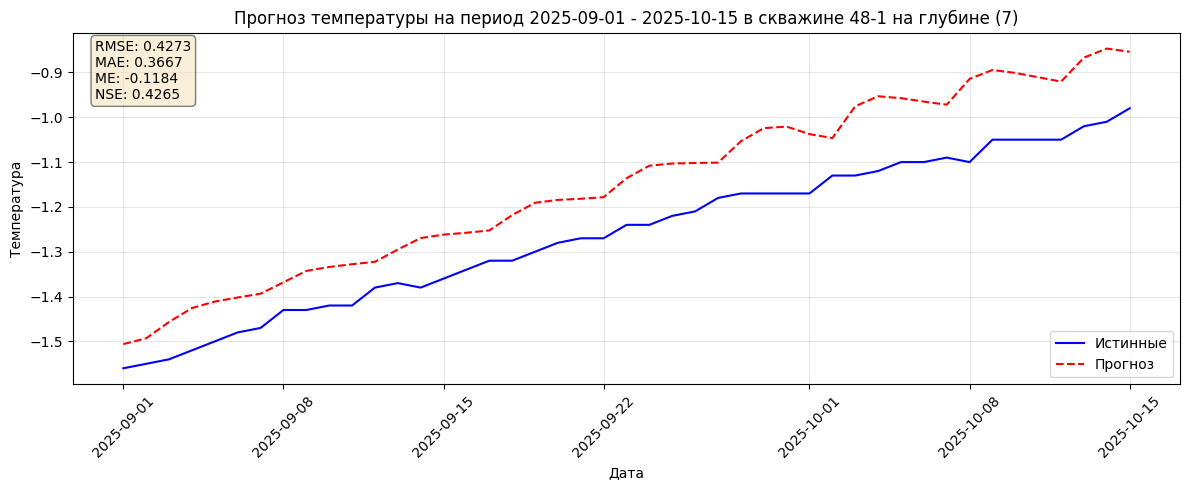

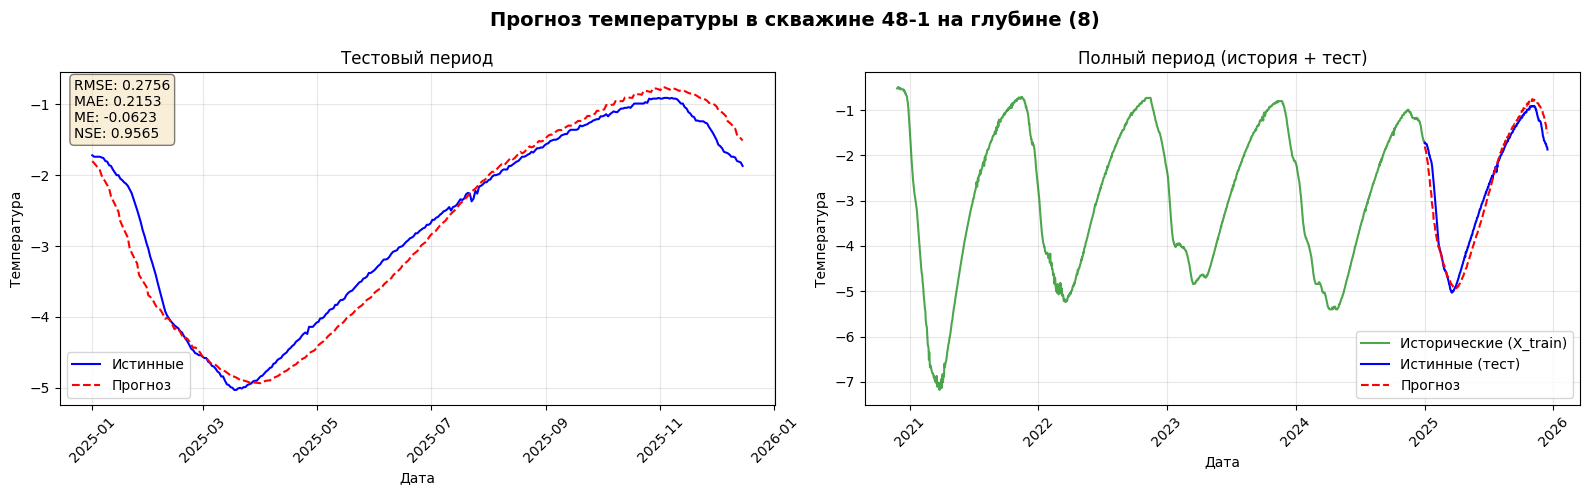

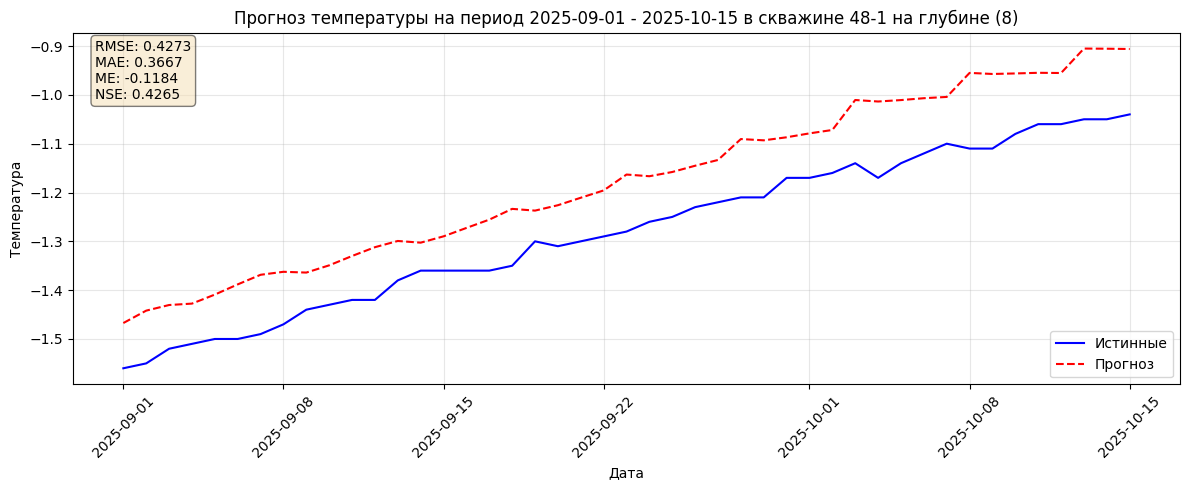

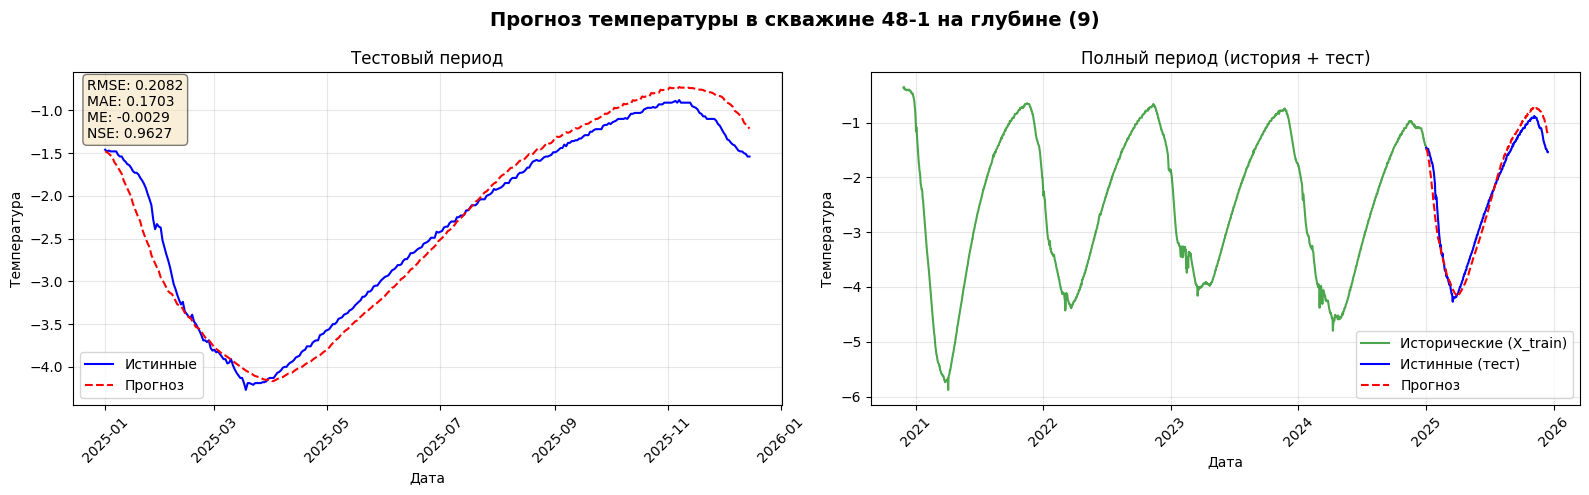

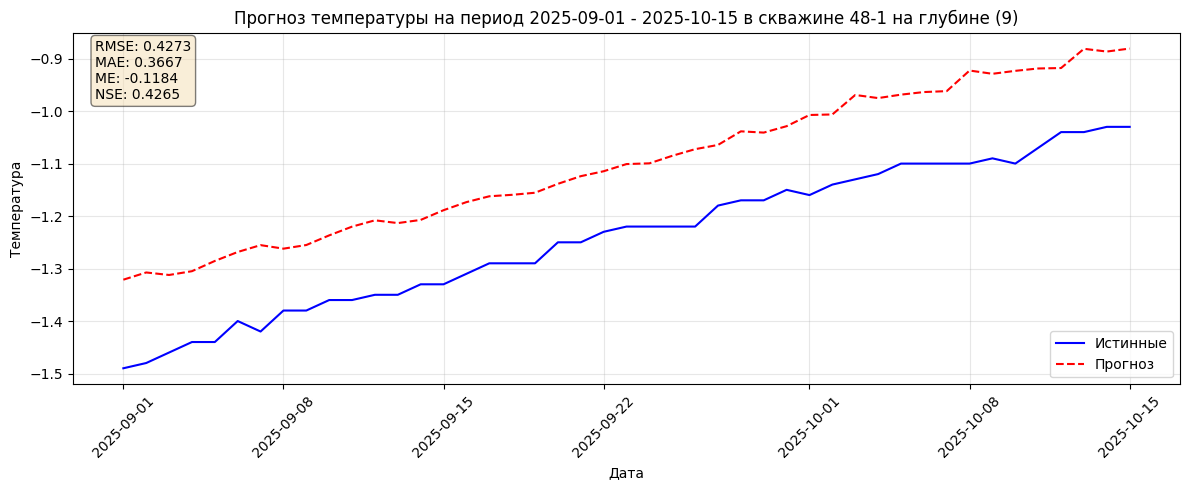

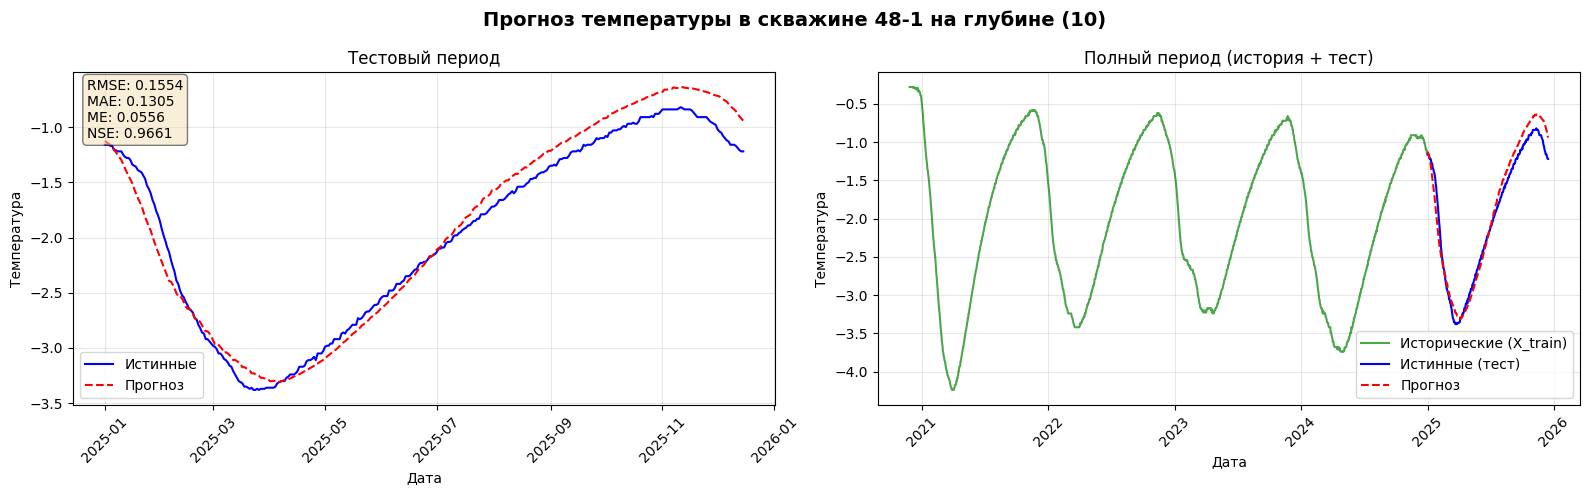

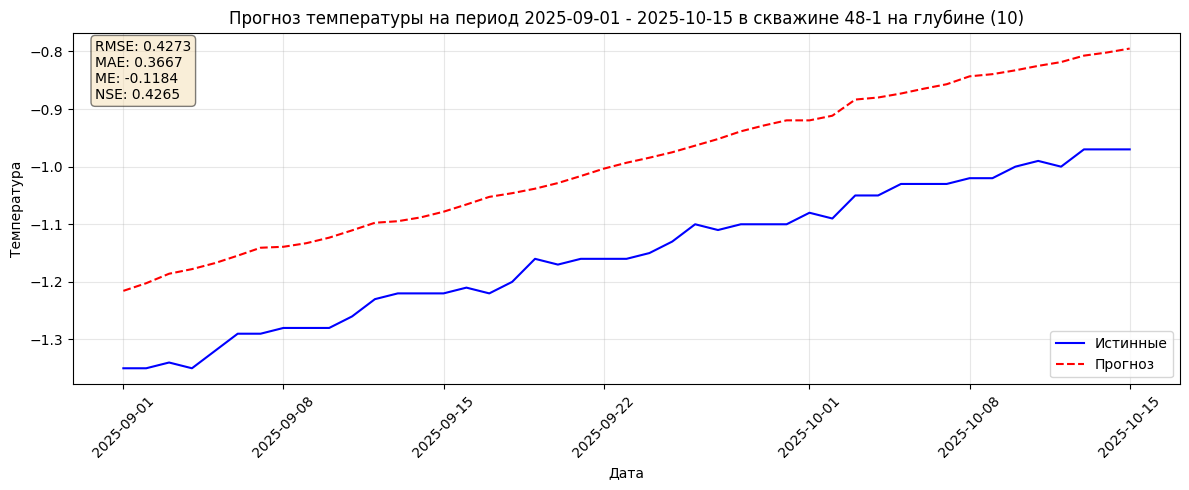

In [10]:
y_pred = predict_seq2seq(
    model=model,
    df_history=df_val,
    df_test=df_test,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    feature_cols=feature_cols,
    target_cols=target_cols,
    history_len=history_len,
    horizon=horizon,
    device=device,
)
y_true = df_test[target_cols]

evaluate_and_plot_full_forecast(
    y_true=y_true,
    y_pred=y_pred,
    target_cols=target_cols,
    df_train_full=df_train_full,
    required_interval=('2025-09-01', '2025-10-15'),
    borehole_name=borehole_name
)